<a href="https://colab.research.google.com/github/jamiroquai1225/Forecasting/blob/main/%EC%A0%9C%EC%A3%BC%EA%B3%B5%ED%95%AD_%EB%AC%BC%EB%8F%99%EB%9F%89_%EC%98%88%EC%B8%A1_%EC%88%98%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [ ]:
 %matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import matplotlib
import pmdarima as pm

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import median_absolute_error, mean_squared_log_error
%matplotlib inline
import itertools
import warnings

In [ ]:
data_df = pd.read_excel('C:/Users/vpsxl/Desktop/airport.xlsx')
data = data_df
print(data)

          ds      y
0    2005-01  28387
1    2005-02  23249
2    2005-03  31961
3    2005-04  29123
4    2005-05  24920
..       ...    ...
209  2022-06  17293
210  2022-07  17188
211  2022-08  19164
212  2022-09  17064
213  2022-10  18995

[214 rows x 2 columns]


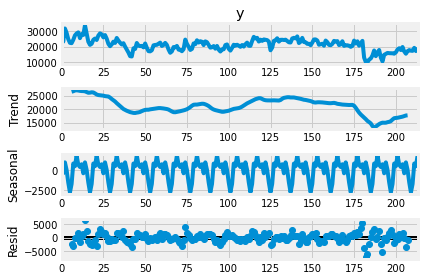

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform additive decomposition
decomp = seasonal_decompose(data['y'], period=12)

# Plot decomposition
decomp.plot();
plt.tight_layout();

<ipython-input-15-c8b2c57bdbce>:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
No handles with labels found to put in legend.


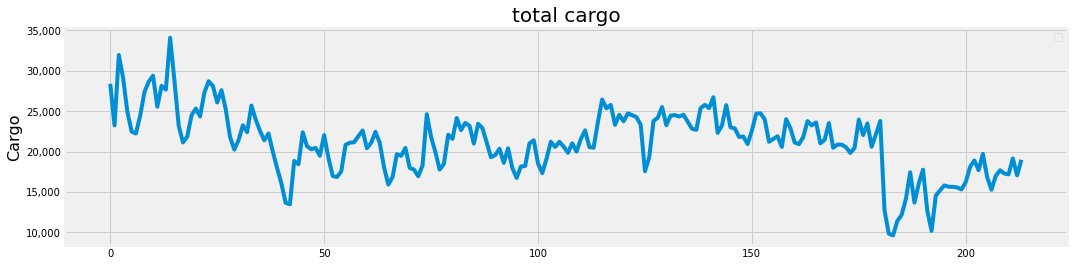

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(data['y'])
plt.title('total cargo', fontsize=20)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.ylabel('Cargo', fontsize=16)
plt.legend()

In [ ]:
data['ds']= pd.to_datetime(data['ds'])
print(data)

            ds      y
0   2005-01-01  28387
1   2005-02-01  23249
2   2005-03-01  31961
3   2005-04-01  29123
4   2005-05-01  24920
..         ...    ...
209 2022-06-01  17293
210 2022-07-01  17188
211 2022-08-01  19164
212 2022-09-01  17064
213 2022-10-01  18995

[214 rows x 2 columns]


In [ ]:
df = data
df = df.rename(columns={'ds': 'ds', 'y': 'y'})[['ds', 'y']]
df['ds'] =df['ds'].dt.tz_localize(None)
df = df.set_index('ds')
print(df)

                y
ds               
2005-01-01  28387
2005-02-01  23249
2005-03-01  31961
2005-04-01  29123
2005-05-01  24920
...           ...
2022-06-01  17293
2022-07-01  17188
2022-08-01  19164
2022-09-01  17064
2022-10-01  18995

[214 rows x 1 columns]


In [ ]:
df_train = df[0:160]
df_test = df[160:214]

In [ ]:
df_train

,y
ds,
2005-01-01,28387
2005-02-01,23249
2005-03-01,31961
2005-04-01,29123
2005-05-01,24920
...,...
2017-12-01,21575
2018-01-01,21900
2018-02-01,20578


In [ ]:
#SARIMA(0, 1, 1)x(0, 1, 1, 12)
mod = sm.tsa.statespace.SARIMAX(df_train,
                                order=(0, 1, 1),
                                seasonal_order=(0, 1, 1, 12))
results = mod.fit()
print(results.summary().tables[1])

C:\Users\vpsxl\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vpsxl\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2070      0.081     -2.541      0.011      -0.367      -0.047
ma.S.L12      -0.4044      0.051     -7.948      0.000      -0.504      -0.305
sigma2      3.807e+06   4.25e+05      8.953      0.000    2.97e+06    4.64e+06


In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  160
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1312.757
Date:                            Mon, 12 Dec 2022   AIC                           2631.514
Time:                                    15:33:57   BIC                           2640.485
Sample:                                01-01-2005   HQIC                          2635.159
                                     - 04-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2070      0.081     -2.541      0.011      -0.367      -0.047
ma.S.L12      -0.4044      0.051     -7.948      0.000      -0.504      -0.305
sigma2      3.807e+06   4.25e+05      8.953      0.000    2.97e+06    4.64e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                29.39
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.47   Skew:                            -0.61
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

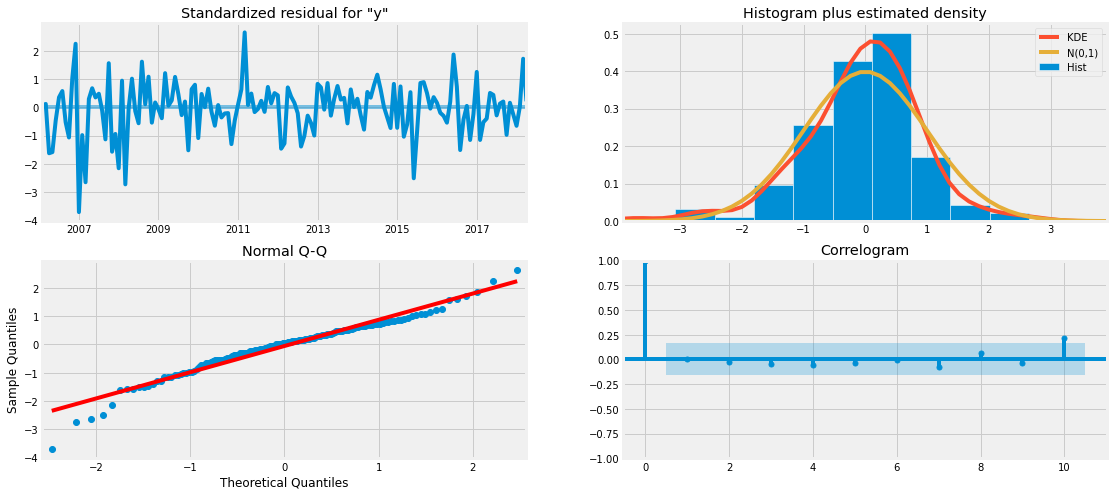

In [ ]:
results.plot_diagnostics(figsize=(17, 8))
plt.show()

In [ ]:
sarima = SARIMAX(df_train,
                 order=(0,1,1),
                 seasonal_order=(0,1,1,12),
                 enforce_stationarity=True,
                 enforce_invertibility=True)

predictions = sarima.fit().predict()

C:\Users\vpsxl\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vpsxl\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
sarima1 = sarima.fit().predict(start=pd.to_datetime('2018-05-01'), end = pd.to_datetime('2022-10-01'), dynamic=False)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
from math import sqrt
mape = sqrt(mean_absolute_percentage_error(sarima1, df_test))
print(mape)

0.485683503687075


In [ ]:
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(df_test, sarima1)**0.5
print(rmse)

6834.575246554867


<ipython-input-122-59aa3dccebcc>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


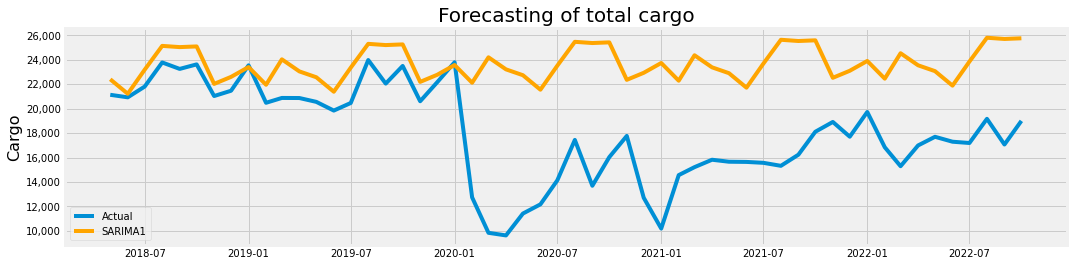

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(df_test, label="Actual")
plt.plot(sarima1, label="SARIMA1", color = "orange")
plt.title('Forecasting of total cargo', fontsize=20)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.ylabel('Cargo', fontsize=16)
plt.legend()

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(df_test, label="Actual")
plt.plot(sarima1, label="SARIMA1", color = "orange")
plt.title('Forecasting of total cargo', fontsize=20)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.ylabel('Cargo', fontsize=16)
plt.legend()

,y
ds,
2005-01-01,28387
2005-02-01,23249
2005-03-01,31961
2005-04-01,29123
2005-05-01,24920
...,...
2017-12-01,21575
2018-01-01,21900
2018-02-01,20578


In [ ]:
df_train = df[0:200]
df_test = df[200:214]

In [ ]:
df_train_prophet = df_train.reset_index()

In [ ]:
df_train1 = df_train_prophet

In [ ]:
df_prophet = df_train.reset_index()

In [ ]:
prophet = Prophet(seasonality_mode = 'additive',
                     yearly_seasonality = True,
                     changepoint_prior_scale = 0.4776319)
prophet.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_data = prophet.make_future_dataframe(periods = 14, freq = 'M')
forecast_data = prophet.predict(future_data)
# forecast_data.tail(5)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


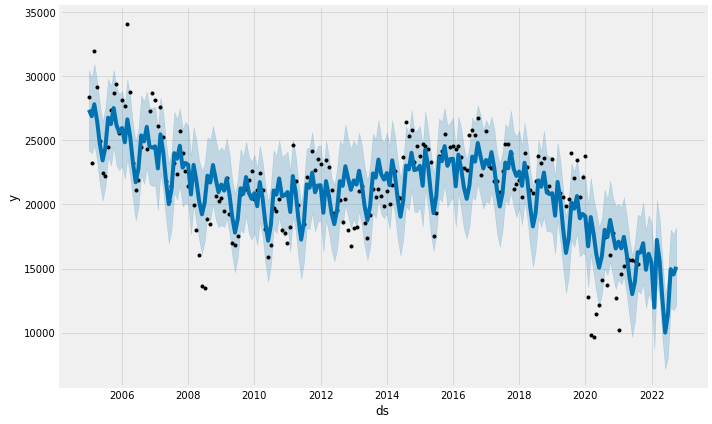

In [ ]:
m = Prophet()
m.fit(df_prophet)
future = m.make_future_dataframe(14, freq='M')
forecast = m.predict(future)
fig = m.plot(forecast)

# plt.savefig('C:/Users/vpsxl/Desktop/pro.png')


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
from math import sqrt
mape = sqrt(mean_absolute_percentage_error(pro1, df_test))
print(mape)

0.4414531725775632


In [ ]:
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(pro1, df_test)**0.5
print(rmse)

5214.575966703822


<ipython-input-168-3852bb9c3df5>:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


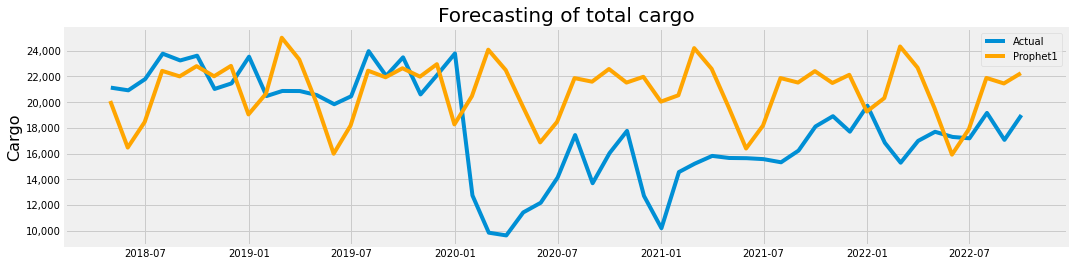

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(df_test, label="Actual")
plt.plot(pro1, label="Prophet1", color = "orange")
plt.title('Forecasting of total cargo', fontsize=20)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.ylabel('Cargo', fontsize=16)
plt.legend()

In [ ]:
pro2 = pd.DataFrame(pro1)
pro2.to_excel(excel_writer='C:/Users/vpsxl/Desktop/pro.xlsx')